In [1]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import kblock_ising_model as kb
from common_imports import *


In [59]:
g_linspace = np.linspace(0,1,20)
L = 100
k = kb.k_vals(L)
Us = [kb.U(k,gi) for gi in g_linspace]

ns = np.arange(2,13)


  0%|          | 0/11 [00:00<?, ?it/s]/home/kristian/Desktop/subsystem_loschmidt_echo/scripts/0_correlation_length_withN/../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 11/11 [00:01<00:00,  5.81it/s]


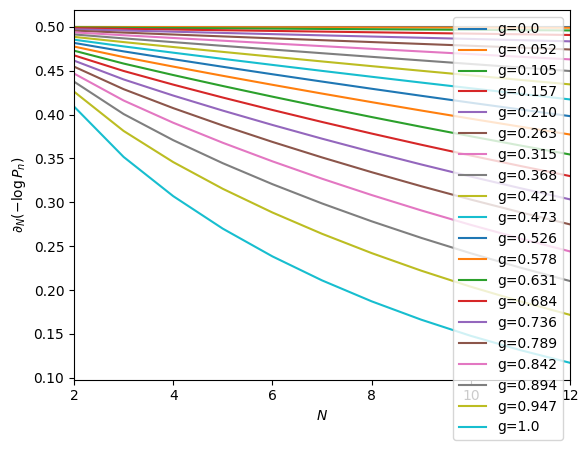

In [60]:
# # --- plot 1: non-derivatives ---
# plt.figure()
# for g, U in zip(g_linspace, Us):
#     dat = np.array([-np.log(kb.P_n(ni, U, k))  for ni in tqdm(ns)])
#     plt.plot(ns, dat, label=f"g={str(g)[:5]}")
# plt.xlabel(r"$N$")
# plt.ylabel(r"$-\log P_n $")
# plt.xlim(ns[0], ns[-1])
# #loglog()
# plt.legend()

# --- plot 2: derivatives ---
plt.figure()
grads = []
for g, U in zip(g_linspace, Us):
    dat = np.array([kb.P_n(ni, U, k)  for ni in tqdm(ns)])
    grads.append(dat)
    plt.plot(ns, dat, label=f"g={str(g)[:5]}")
plt.xlabel(r"$N$")
plt.ylabel(r"$\partial_N(-\log P_n )$")
plt.xlim(ns[0], ns[-1])
#loglog()
plt.legend()


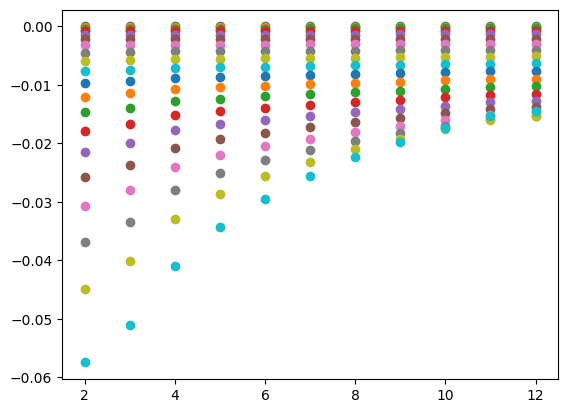

In [71]:
for p,g in zip(grads,g_linspace):
    #plot(ns,-log(p))
    #p = -log(p)
    d1 = np.gradient(p,ns)
    d2 = np.gradient(d1,ns)
    scatter(ns,d1)


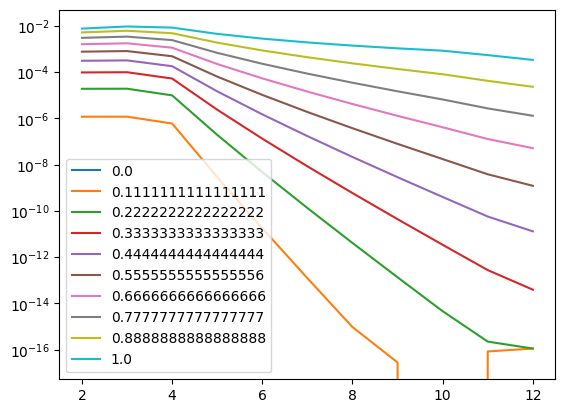

In [31]:
for gr,g in zip(grads,g_linspace):
    plot(ns,np.abs(array(gr)),label=g)
legend()
yscale("log")